# Phase 1: Domain Knowledge, Basic EDA and Univariate Analysis

**Project:** CogniLend – Loan Approval Decision-Support System
**Input:** `data/raw/loan_applications_raw.csv`
**Output:** `phase1/preprocessing_phase1_report.md` and the plots in `phase1/plots/`

**Rule for this phase:** we only **study** the data. We do not clean, fill, drop or change anything in the real data (`df`).
If a plot needs a small fix (for example removing extra spaces from labels), we do it on a **temporary copy** only.
All real cleaning is done in Phase 3.

| Phase | Work |
|---|---|
| **1 (this notebook)** | Domain knowledge, basic EDA (7 questions), univariate analysis |
| 2 | Bivariate and multivariate analysis |
| 3 | Cleaning and transformation |
| 4 | Feature engineering |

## Step 0: Import libraries and load the data

In [1]:
import os
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# colours used in all plots
MAIN_COLOR = '#2a78d6'     # blue  -> normal bars and histograms
PROBLEM_COLOR = '#eb6834'  # orange -> used to point out a problem
MISSING_COLOR = '#b5b5b5'  # grey  -> missing values

sns.set_style('whitegrid')
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['grid.color'] = '#e6e6e6'
plt.rcParams['axes.edgecolor'] = '#999999'

# folder where plots are saved for the report
PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)

In [ ]:
DATA_PATH = '../../dataset/loan_applications_raw.csv'

df = pd.read_csv(DATA_PATH)
print('Data loaded from:', DATA_PATH)

Data loaded from: ../data/raw/loan_applications_raw.csv


## Part A: Domain knowledge

**What is the problem?**
A bank receives many loan applications. For each one, a loan officer must decide: **approve or reject**.
Our system will predict this decision, show the reason (decision path), check bank/RBI rules separately from the model,
save every decision for audit, and check that different groups of applicants are treated fairly.

**How does an Indian bank check a loan application? (the 5 Cs of credit)**

| C | Question the bank asks | Columns in our data |
|---|---|---|
| Character | Does this person repay loans on time? | CIBIL_Score |
| Capacity | Can this person pay one more EMI every month? | Monthly_Income, Coapplicant_Income, Existing_EMI |
| Capital / stability | Is the job or business stable? | Employment_Type, Work_Experience, Age |
| Collateral | What can the bank sell if the loan is not repaid? | Collateral_Value, Loan_Type |
| Conditions | What exactly is asked for? | Loan_Type, Loan_Amount, Loan_Tenure |

**Important terms**

| Term | Simple meaning |
|---|---|
| EMI | Fixed amount paid every month to repay a loan |
| FOIR | (All EMIs including the new one) ÷ monthly income. Lower is safer |
| CIBIL score | Credit score from 300 to 900. Higher is better. **−1 means no credit history (new to credit, NTC)** |
| LTV | Loan amount ÷ value of the property. RBI limits this for home loans |
| Collateral | Property or vehicle given as security. Personal loans have no collateral (unsecured) |
| Co-applicant | Second person (often spouse or parent) whose income is added |
| Tenure | Number of months to repay the loan |
| Salaried / SEP / SENP | Job holder / self-employed professional (doctor, CA) / self-employed business owner |

The full domain notes, bank norms and sources are in the Phase 1 report.

**Valid values for each column (from domain knowledge).**
We write them in code so we can **check** the data against them in Part C. In this phase we only count the bad values; we do not fix them.

In [3]:
# (lowest valid value, highest valid value). None = no upper limit.
valid_range = {
    'Age':                (18, 75),       # adult applicants only
    'Work_Experience':    (0, 50),        # years
    'Monthly_Income':     (1, None),      # must be more than 0
    'Coapplicant_Income': (1, None),      # blank = no co-applicant
    'Existing_EMI':       (0, None),      # 0 = no existing loan
    'CIBIL_Score':        (300, 900),     # -1 is also allowed (no credit history)
    'Loan_Amount':        (1, None),
    'Loan_Tenure':        (6, 360),       # months, usually a multiple of 12
    'Collateral_Value':   (1, None),      # blank = unsecured loan
}

valid_categories = {
    'Gender':          ['Male', 'Female', 'Transgender'],
    'Marital_Status':  ['Married', 'Single', 'Divorced', 'Widowed'],
    'Dependents':      ['0', '1', '2', '3+'],
    'Employment_Type': ['Salaried', 'Self-Employed Professional', 'Self-Employed Non-Professional'],
    'Loan_Type':       ['Home Loan', 'Vehicle Loan', 'Personal Loan', 'Business Loan'],
    'Property_Area':   ['Urban', 'Semi-Urban', 'Rural'],
    'Loan_Status':     ['Approved', 'Rejected'],
}

for col in valid_categories:
    print(col, '->', valid_categories[col])

Gender -> ['Male', 'Female', 'Transgender']
Marital_Status -> ['Married', 'Single', 'Divorced', 'Widowed']
Dependents -> ['0', '1', '2', '3+']
Employment_Type -> ['Salaried', 'Self-Employed Professional', 'Self-Employed Non-Professional']
Loan_Type -> ['Home Loan', 'Vehicle Loan', 'Personal Loan', 'Business Loan']
Property_Area -> ['Urban', 'Semi-Urban', 'Rural']
Loan_Status -> ['Approved', 'Rejected']


## Part B: Basic EDA – the 7 questions

### Q1. How big is the data?

In [4]:
n_rows = df.shape[0]
n_cols = df.shape[1]
print('Rows   :', n_rows)
print('Columns:', n_cols)
print('Memory used: %.2f MB' % (df.memory_usage(deep=True).sum() / 1024 / 1024))

Rows   : 10000
Columns: 17
Memory used: 6.19 MB


**Observation (Q1):** The data has **10,000 rows and 17 columns** (Loan_ID + 15 input columns + Loan_Status). It is small enough to load fully in memory (about 6 MB).

### Q2. How does the data look?

In [5]:
df.head()

,Loan_ID,Age,Gender,Marital_Status,Dependents,Employment_Type,Work_Experience,Monthly_Income,Coapplicant_Income,Existing_EMI,CIBIL_Score,Loan_Type,Loan_Amount,Loan_Tenure,Collateral_Value,Property_Area,Loan_Status
0,LN2025102971,40.0,Transgender,Married,0,salaried,18.0,45800.0,NaN,1900.0,821.0,Home Loan,1440000.0,240.0,2080000.0,Rural,Approved
1,LN2025107793,46.0,Male,Married,2,Self-Employed Non-Professional,19.0,38400.0,NaN,0.0,748.0,Personal Loan,280000.0,36.0,NaN,Semi-Urban,Approved
2,LN2025102488,24.0,Male,Single,0,Salaried,4.0,39400.0,23600.0,0.0,851.0,Home Loan,2690000.0,240.0,3710000.0,Rural,Approved
3,LN2025106297,34.0,Male,Married,0,Self-Employed Non-Professional,10.0,51000.0,NaN,0.0,747.0,Home Loan,2180000.0,240.0,2940000.0,Urban,Approved
4,LN2025108470,23.0,Male,Single,0,Salaried,0.0,43500.0,NaN,0.0,801.0,Personal Loan,460000.0,36.0,NaN,Semi-Urban,Rejected


In [6]:
df.sample(5, random_state=7)

,Loan_ID,Age,Gender,Marital_Status,Dependents,Employment_Type,Work_Experience,Monthly_Income,Coapplicant_Income,Existing_EMI,CIBIL_Score,Loan_Type,Loan_Amount,Loan_Tenure,Collateral_Value,Property_Area,Loan_Status
1977,LN2025109765,44.0,Female,Married,1,Salaried,19.0,29800.0,NaN,4200.0,757.0,Home Loan,1030000.0,180.0,NaN,Rural,Approved
3880,LN2025100410,41.0,Male,Married,1,Salaried,19.0,48800.0,NaN,0.0,684.0,Personal Loan,300000.0,36.0,NaN,Urban,Approved
52,LN2025109643,37.0,Male,Married,3+,Salaried,12.0,47400.0,16400.0,0.0,788.0,Personal,340000.0,60.0,NaN,Urban,Approved
2551,LN2025107274,38.0,M,Married,1,Salaried,16.0,68100.0,43800.0,0.0,799.0,Home Loan,2980000.0,240.0,5350000.0,Semi-Urban,Approved
2246,LN2025100857,35.0,Male,Married,3+,Salaried,10.0,40200.0,60100.0,0.0,773.0,Home Loan,2950000.0,180.0,4780000.0,Semi-Urban,Approved


**Observation (Q2):**
- Each row is one loan application with an ID like `LN2025102971`.
- We can already see messy text: `salaried` (small letters), `M` instead of `Male`, `Personal` instead of `Personal Loan`, and `Rural ` with an extra space.
- Coapplicant_Income and Collateral_Value are blank (`NaN`) in many rows.
- Loan_Amount is shown like `1440000.0`, which looks like a number, but Q3 shows it is stored as text.

### Q3. What is the data type of each column?

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             10000 non-null  str    
 1   Age                 10000 non-null  float64
 2   Gender              9821 non-null   str    
 3   Marital_Status      9882 non-null   str    
 4   Dependents          9760 non-null   str    
 5   Employment_Type     10000 non-null  str    
 6   Work_Experience     9699 non-null   float64
 7   Monthly_Income      9901 non-null   float64
 8   Coapplicant_Income  3213 non-null   float64
 9   Existing_EMI        9748 non-null   float64
 10  CIBIL_Score         9901 non-null   float64
 11  Loan_Type           10000 non-null  str    
 12  Loan_Amount         9848 non-null   str    
 13  Loan_Tenure         9819 non-null   float64
 14  Collateral_Value    5750 non-null   float64
 15  Property_Area       9851 non-null   str    
 16  Loan_Status     

In [8]:
# Loan_Amount should be a number, but pandas read it as text. Let us find out why.
amount_as_number = pd.to_numeric(df['Loan_Amount'], errors='coerce')
not_a_number = df['Loan_Amount'][amount_as_number.isnull() & df['Loan_Amount'].notnull()]

amount_text_count = len(not_a_number)
amount_rs_count = not_a_number.str.startswith('Rs').sum()
print('Loan_Amount values that are not plain numbers:', amount_text_count)
print('   ...of these, values starting with "Rs.":', amount_rs_count)
print()
print('Some examples:')
print(not_a_number.head(8).to_string())

Loan_Amount values that are not plain numbers: 584
   ...of these, values starting with "Rs.": 94

Some examples:
10          1,30,000
41         12,20,000
101    Rs. 27,90,000
110         3,40,000
117         5,40,000
127         3,40,000
130         4,10,000
134        15,40,000


In [9]:
# Dependents is also text because of the value "3+"
print('Unique values in Dependents:', df['Dependents'].dropna().unique())
dependents_3plus = (df['Dependents'] == '3+').sum()
print('Rows with "3+":', dependents_3plus)

Unique values in Dependents: <StringArray>
['0', '2', '3+', '1']
Length: 4, dtype: str
Rows with "3+": 1840


**Observation (Q3):**
- 8 columns are numbers (`float64`) and 9 columns are text.
- **Loan_Amount should be a number but is stored as text**, because 584 values are written like `12,20,000` (Indian comma style) and 94 of them also start with `Rs.`.
- **Dependents is text** because of the value `3+` (1,840 rows).
- Age, Work_Experience, CIBIL_Score and Loan_Tenure are whole numbers but stored as decimals (`40.0`).
- No type was changed in this phase. All of this goes to Phase 3.

### Q4. Are there any missing values?

In [10]:
missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
missing_table = missing_table[missing_table['missing_count'] > 0]
missing_table = missing_table.sort_values('missing_count', ascending=False)

print('Columns with missing values:', len(missing_table), 'out of', n_cols)
print('Total missing cells:', missing.sum())
missing_table

Columns with missing values: 13 out of 17
Total missing cells: 12825


,missing_count,missing_percent
Coapplicant_Income,6787,67.87
Collateral_Value,4250,42.50
Work_Experience,301,3.01
Existing_EMI,252,2.52
Dependents,240,2.40
Loan_Tenure,181,1.81
Gender,179,1.79
Loan_Amount,152,1.52
Property_Area,149,1.49
Marital_Status,118,1.18


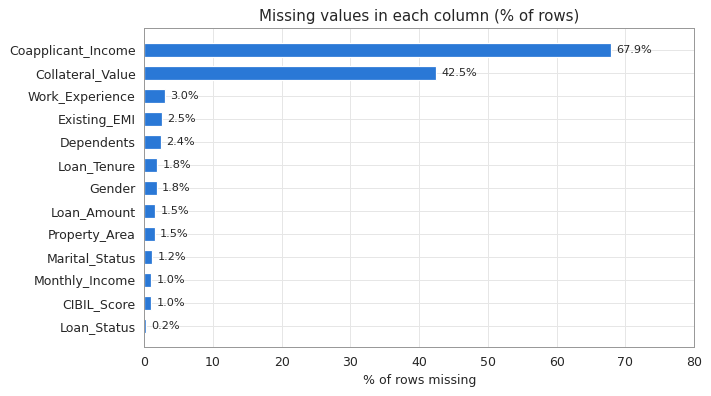

In [11]:
plt.figure(figsize=(8, 4.5))
bars = plt.barh(missing_table.index[::-1], missing_table['missing_percent'][::-1], color=MAIN_COLOR, height=0.6)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.8, bar.get_y() + bar.get_height() / 2, str(round(width, 1)) + '%', va='center', fontsize=9)
plt.title('Missing values in each column (% of rows)')
plt.xlabel('% of rows missing')
plt.xlim(0, 80)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'q4_missing_values.png'), dpi=150)
plt.show()

**Observation (Q4):**
- 13 of 17 columns have missing values (12,825 missing cells in total).
- Two columns are **very** empty: **Coapplicant_Income 67.9%** and **Collateral_Value 42.5%**. This is too much to be random typing mistakes.
  Domain idea: a blank co-applicant income may mean "no co-applicant", and a blank collateral may mean "unsecured loan" (personal loans have no collateral). **Phase 2 must check this** against Loan_Type.
- The other columns have small gaps (1–3%), which look random.
- **18 rows have no Loan_Status (target).** We cannot learn from these rows.

### Q5. How does the data look mathematically?

In [12]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,38.25,28.81,-30.0,31.0,37.0,43.0,999.0
Work_Experience,9699.0,13.55,8.67,-3.0,7.0,13.0,19.0,71.0
Monthly_Income,9901.0,73326.60,65445.08,-212100.0,35400.0,55100.0,87700.0,1072200.0
Coapplicant_Income,3213.0,42255.28,27966.70,4600.0,24000.0,35400.0,52900.0,550900.0
Existing_EMI,9748.0,6128.22,12859.96,0.0,0.0,0.0,7300.0,212900.0
CIBIL_Score,9901.0,695.50,311.32,-1.0,683.0,733.0,777.0,9999.0
Loan_Tenure,9819.0,91.61,86.68,10.0,36.0,60.0,120.0,360.0
Collateral_Value,5750.0,3207523.48,4279389.43,50000.0,580000.0,1720000.0,4270000.0,60850000.0


In [13]:
# text columns
df.select_dtypes(exclude='number').describe().T

,count,unique,top,freq
Loan_ID,10000,9865,LN2025105700,2
Gender,9821,25,Male,6296
Marital_Status,9882,25,Married,6669
Dependents,9760,4,0,2737
Employment_Type,10000,27,Salaried,5452
Loan_Type,10000,36,Personal Loan,2908
Loan_Amount,9848,1172,140000.0,139
Property_Area,9851,24,Urban,4424
Loan_Status,9982,2,Approved,5838


**Observation (Q5):** The summary shows impossible values straight away:
- **Age** goes from **−30 to 999**.
- **Monthly_Income** has a minimum of **−2,12,100** (negative income is not possible).
- **CIBIL_Score** goes up to **9999** (the real range is 300–900). The minimum is **−1** (meaning no credit history).
- **Work_Experience** goes from **−3 to 71** years.
- **Existing_EMI** has a median of 0, so more than half of applicants have no existing loan.
- **Loan_Tenure** has a minimum of **10** months, which is unusual.
- Loan_ID has **9,865 unique values in 10,000 rows**, so some IDs repeat (see Q6).

### Q6. Are there duplicate values?

In [14]:
n_dup_rows = df.duplicated().sum()
n_dup_ids = df['Loan_ID'].duplicated().sum()
print('Fully duplicate rows        :', n_dup_rows)
print('Loan_IDs that appear again  :', n_dup_ids)

# Are the repeated Loan_IDs exact copies, or the same ID with different data?
rows_with_repeated_id = df[df['Loan_ID'].duplicated(keep=False)]
different_data = len(rows_with_repeated_id.drop_duplicates()) - rows_with_repeated_id['Loan_ID'].nunique()
print('Same Loan_ID but different data:', different_data)

Fully duplicate rows        : 135
Loan_IDs that appear again  : 135
Same Loan_ID but different data: 0


**Observation (Q6):** There are **135 fully duplicate rows**. The same 135 Loan_IDs repeat, and **every repeated ID is an exact copy** (no ID has two different versions of the data).
So these look like the same application submitted twice. They should be removed in Phase 3.

### Q7. How is the correlation between columns?

This is only a **first look** using the numeric columns as they are. Loan_Amount is not included because it is stored as text. Detailed relationship study is Phase 2.

In [15]:
corr = df.corr(numeric_only=True).round(2)
corr

,Age,Work_Experience,Monthly_Income,Coapplicant_Income,Existing_EMI,CIBIL_Score,Loan_Tenure,Collateral_Value
Age,1.00,0.28,0.11,-0.00,0.05,0.01,-0.04,0.06
Work_Experience,0.28,1.00,0.31,-0.01,0.17,0.03,-0.09,0.13
Monthly_Income,0.11,0.31,1.00,0.06,0.33,0.03,-0.04,0.46
Coapplicant_Income,-0.00,-0.01,0.06,1.00,0.13,-0.00,0.00,0.26
Existing_EMI,0.05,0.17,0.33,0.13,1.00,0.02,-0.00,0.18
CIBIL_Score,0.01,0.03,0.03,-0.00,0.02,1.00,-0.01,0.03
Loan_Tenure,-0.04,-0.09,-0.04,0.00,-0.00,-0.01,1.00,0.43
Collateral_Value,0.06,0.13,0.46,0.26,0.18,0.03,0.43,1.00


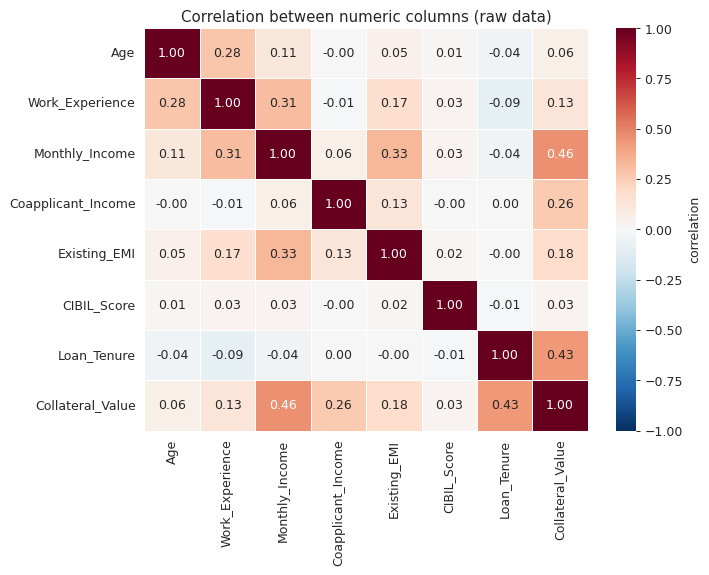

In [16]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'correlation'})
plt.title('Correlation between numeric columns (raw data)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'q7_correlation_heatmap.png'), dpi=150)
plt.show()

**Observation (Q7) – first look only:**
- The strongest links are **Monthly_Income ↔ Collateral_Value (0.46)**, **Loan_Tenure ↔ Collateral_Value (0.43)** and **Monthly_Income ↔ Existing_EMI (0.33)**. These make sense: richer people buy costlier property, and big property loans have long tenures.
- **Age ↔ Work_Experience is only 0.28**, which is surprisingly low because older people should have more experience. The impossible ages (like 999) probably spoil this number. **Phase 2 should re-check it without the bad values.**
- CIBIL_Score has almost no link with any other column.
- Loan_Amount is missing from this table because it is stored as text.

## Part C: Univariate analysis

We study **one column at a time**: how its values are spread, what is common, what is rare, and what looks wrong.

### C1. Target column: Loan_Status

In [17]:
def plot_category_counts(series, title, file_name, order=None):
    # bar chart of counts with % on top; missing values shown as a grey bar
    counts = series.value_counts()
    if order is not None:
        counts = counts.reindex(order).fillna(0).astype(int)
    labels = list(counts.index)
    values = list(counts.values)
    colors = [MAIN_COLOR] * len(values)

    n_missing = series.isnull().sum()
    if n_missing > 0:
        labels.append('Missing')
        values.append(n_missing)
        colors.append(MISSING_COLOR)

    short_labels = []
    for label in labels:
        short_labels.append(textwrap.fill(str(label), 16))

    total = len(series)
    plt.figure(figsize=(max(6.5, 1.4 * len(values)), 4))
    bars = plt.bar(short_labels, values, color=colors, width=0.6)
    for bar, value in zip(bars, values):
        text = str(value) + '\n(' + str(round(value / total * 100, 1)) + '%)'
        plt.text(bar.get_x() + bar.get_width() / 2, value, text, ha='center', va='bottom', fontsize=9)
    plt.title(title)
    plt.ylabel('Number of applications')
    plt.gca().xaxis.grid(False)
    plt.ylim(0, max(values) * 1.2)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, file_name), dpi=150)
    plt.show()

Loan_Status
Approved    5838
Rejected    4144
NaN           18
Name: count, dtype: int64

Loan_Status
Approved    58.49
Rejected    41.51
Name: proportion, dtype: float64


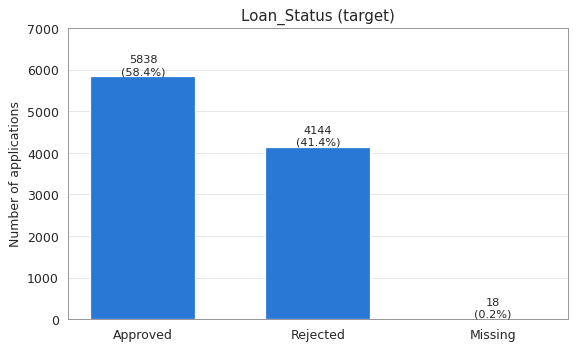

In [18]:
print(df['Loan_Status'].value_counts(dropna=False))
print()
print(df['Loan_Status'].value_counts(normalize=True).round(4) * 100)

n_missing_target = df['Loan_Status'].isnull().sum()
plot_category_counts(df['Loan_Status'], 'Loan_Status (target)', 'uni_target_loan_status.png',
                     order=['Approved', 'Rejected'])

**Observation (C1 – target):**
- **Approved 5,838 (58.5%)**, **Rejected 4,144 (41.5%)**, **missing 18**. (Percentages are of filled rows; the plot shows % of all 10,000 rows.)
- The classes are **mildly imbalanced** (about 1.4 approved for every 1 rejected). This is not severe, but accuracy alone can mislead: a model that always says "Approved" would already get about 58.5%.
- **We should report precision, recall, F1 and ROC-AUC later, not only accuracy.**

### C2. Categorical columns

First we look at the **raw spellings** in each text column. `repr()` is used so that extra spaces become visible (for example `'Male '`).

In [19]:
cat_cols = ['Gender', 'Marital_Status', 'Dependents', 'Employment_Type', 'Loan_Type', 'Property_Area']

for col in cat_cols:
    print('=' * 70)
    print(col, '| different raw values:', df[col].nunique(), '| missing:', df[col].isnull().sum())
    print('-' * 70)
    for value, count in df[col].value_counts().items():
        print('   ', repr(value), '->', count)

Gender | different raw values: 25 | missing: 179
----------------------------------------------------------------------
    'Male' -> 6296
    'Female' -> 2507
    'M' -> 201
    'male' -> 175
    'MALE' -> 170
    'F' -> 76
    'FEMALE' -> 71
    'female' -> 70
    'Male  ' -> 64
    'Male ' -> 60
    'Transgender' -> 58
    'Female  ' -> 26
    'Female ' -> 24
    'male  ' -> 4
    'male ' -> 3
    'M  ' -> 3
    'female  ' -> 2
    'MALE  ' -> 2
    'female ' -> 2
    'M ' -> 2
    'TG' -> 1
    'MALE ' -> 1
    'transgender' -> 1
    'F  ' -> 1
    'FEMALE  ' -> 1
Marital_Status | different raw values: 25 | missing: 118
----------------------------------------------------------------------
    'Married' -> 6669
    'Single' -> 2086
    'married' -> 327
    'MARRIED' -> 274
    'Divorced' -> 87
    'Unmarried' -> 83
    'Married  ' -> 74
    'single' -> 72
    'Widowed' -> 71
    'Married ' -> 56
    'Single ' -> 22
    'Single  ' -> 20
    'widowed' -> 12
    'divorced' -> 6
    'W

In [20]:
# Count rows that have extra spaces or a spelling that is not in our valid list
spelling_table = []
for col in cat_cols + ['Loan_Status']:
    values = df[col].dropna()
    has_space = (values != values.str.strip()).sum()
    not_valid = (~values.isin(valid_categories[col])).sum()
    spelling_table.append({
        'column': col,
        'raw_spellings': values.nunique(),
        'real_categories': len(valid_categories[col]),
        'rows_with_extra_space': has_space,
        'rows_not_in_valid_list': not_valid,
    })
spelling_table = pd.DataFrame(spelling_table)
spelling_table

,column,raw_spellings,real_categories,rows_with_extra_space,rows_not_in_valid_list
0,Gender,25,3,195,960
1,Marital_Status,25,4,195,969
2,Dependents,4,4,0,0
3,Employment_Type,27,3,198,983
4,Loan_Type,36,4,202,983
5,Property_Area,24,3,201,966
6,Loan_Status,2,2,0,0


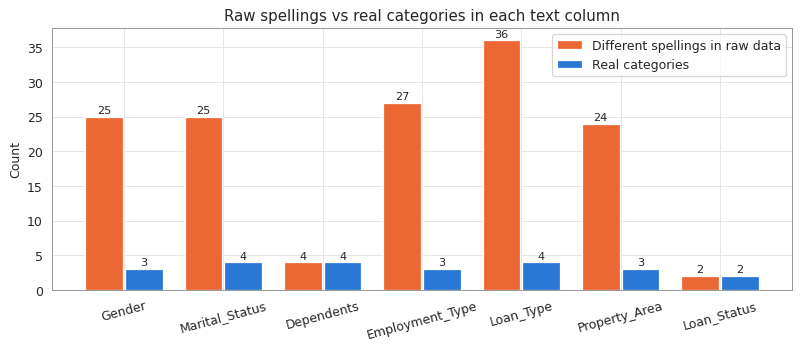

In [21]:
plt.figure(figsize=(9, 4))
x = np.arange(len(spelling_table))
plt.bar(x - 0.2, spelling_table['raw_spellings'], width=0.38, color=PROBLEM_COLOR, label='Different spellings in raw data')
plt.bar(x + 0.2, spelling_table['real_categories'], width=0.38, color=MAIN_COLOR, label='Real categories')
for i in range(len(spelling_table)):
    plt.text(x[i] - 0.2, spelling_table['raw_spellings'][i] + 0.5, str(spelling_table['raw_spellings'][i]), ha='center', fontsize=9)
    plt.text(x[i] + 0.2, spelling_table['real_categories'][i] + 0.5, str(spelling_table['real_categories'][i]), ha='center', fontsize=9)
plt.xticks(x, spelling_table['column'], rotation=15)
plt.ylabel('Count')
plt.title('Raw spellings vs real categories in each text column')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'uni_cat_spellings_summary.png'), dpi=150)
plt.show()

**Observation (spellings):**
- Five text columns have many spellings for a few real categories: **Gender 25 → 3, Marital_Status 25 → 4, Employment_Type 27 → 3, Loan_Type 36 → 4, Property_Area 24 → 3**.
- In each of these columns about **10% of rows** (960 to 983 rows) are not in the correct spelling, and about **2%** (195 to 202 rows) have extra spaces.
- Some spellings need domain knowledge to understand: `Service` = Salaried, `Unmarried` = Single, `SEP`/`SENP`, `HL`/`PL`/`BL`, `MSME Loan` = Business Loan, `Auto Loan`/`Car Loan` = Vehicle Loan.
- **Dependents and Loan_Status are clean** (no spelling problems).

**Basic fix only for plotting.** To draw clear bar charts, we join spellings that mean the same thing (for example `M`, `male`, `MALE ` → `Male`).
This is done on a **temporary copy**. The real `df` is not changed. Proper cleaning will be done in Phase 3 (this map can be reused there).

In [22]:
plot_map = {
    'Gender': {'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female',
               'transgender': 'Transgender', 'tg': 'Transgender'},
    'Marital_Status': {'married': 'Married', 'single': 'Single', 'unmarried': 'Single',
                       'divorced': 'Divorced', 'widowed': 'Widowed'},
    'Dependents': {'0': '0', '1': '1', '2': '2', '3+': '3+'},
    'Employment_Type': {'salaried': 'Salaried', 'service': 'Salaried',
                        'self-employed professional': 'Self-Employed Professional',
                        'self employed professional': 'Self-Employed Professional',
                        'sep': 'Self-Employed Professional',
                        'self-employed non-professional': 'Self-Employed Non-Professional',
                        'self employed business': 'Self-Employed Non-Professional',
                        'business owner': 'Self-Employed Non-Professional',
                        'senp': 'Self-Employed Non-Professional'},
    'Loan_Type': {'home loan': 'Home Loan', 'housing loan': 'Home Loan', 'hl': 'Home Loan',
                  'vehicle loan': 'Vehicle Loan', 'auto loan': 'Vehicle Loan', 'car loan': 'Vehicle Loan',
                  'personal loan': 'Personal Loan', 'personal': 'Personal Loan', 'pl': 'Personal Loan',
                  'business loan': 'Business Loan', 'msme loan': 'Business Loan', 'bl': 'Business Loan'},
    'Property_Area': {'urban': 'Urban', 'semi-urban': 'Semi-Urban', 'semi urban': 'Semi-Urban',
                      'semiurban': 'Semi-Urban', 'rural': 'Rural'},
}


def temp_clean(col):
    # returns a NEW series; df is not changed
    lower_values = df[col].str.strip().str.lower()
    return lower_values.map(plot_map[col])


# check that every raw spelling was mapped (only real missing values should stay empty)
for col in cat_cols:
    cleaned = temp_clean(col)
    not_mapped = cleaned.isnull().sum() - df[col].isnull().sum()
    print(col, '-> spellings not mapped:', not_mapped)

Gender -> spellings not mapped: 0
Marital_Status -> spellings not mapped: 0
Dependents -> spellings not mapped: 0
Employment_Type -> spellings not mapped: 0
Loan_Type -> spellings not mapped: 0
Property_Area -> spellings not mapped: 0


Gender (temporary clean view)
             count  percent
Gender                     
Male          6981    69.81
Female        2780    27.80
NaN            179     1.79
Transgender     60     0.60


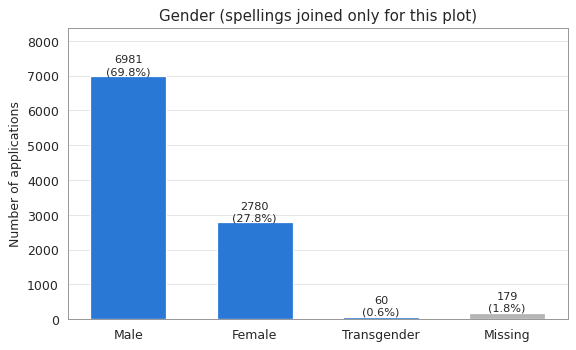

Marital_Status (temporary clean view)
                count  percent
Marital_Status                
Married          7411    74.11
Single           2289    22.89
NaN               118     1.18
Divorced           95     0.95
Widowed            87     0.87


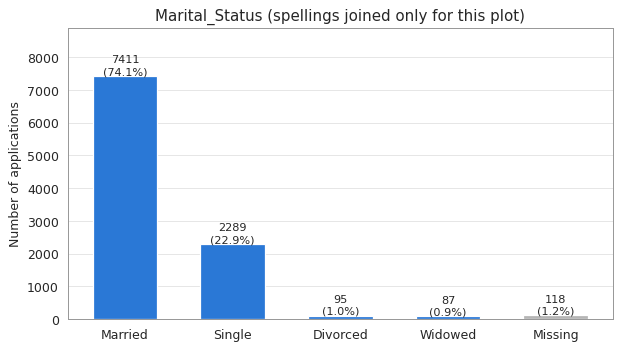

Dependents (temporary clean view)
            count  percent
Dependents                
0            2737    27.37
1            2686    26.86
2            2497    24.97
3+           1840    18.40
NaN           240     2.40


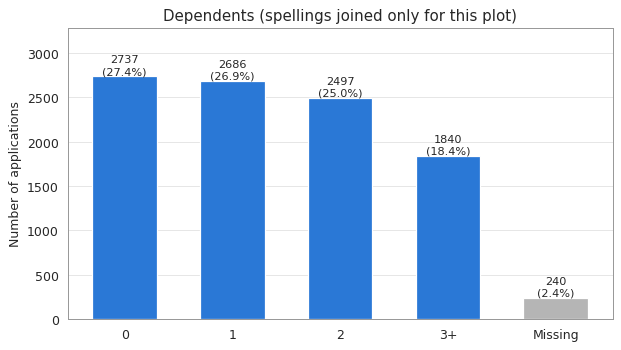

Employment_Type (temporary clean view)
                                count  percent
Employment_Type                               
Salaried                         6048    60.48
Self-Employed Non-Professional   2450    24.50
Self-Employed Professional       1502    15.02


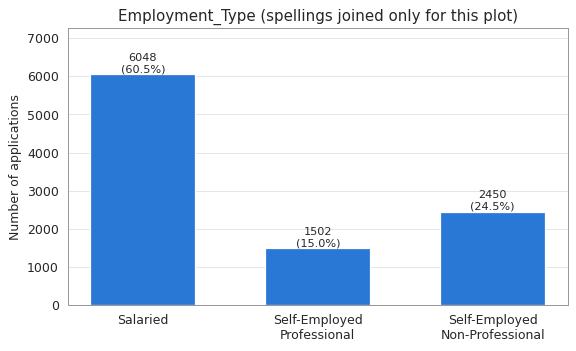

Loan_Type (temporary clean view)
               count  percent
Loan_Type                    
Personal Loan   3215    32.15
Home Loan       2800    28.00
Vehicle Loan    2343    23.43
Business Loan   1642    16.42


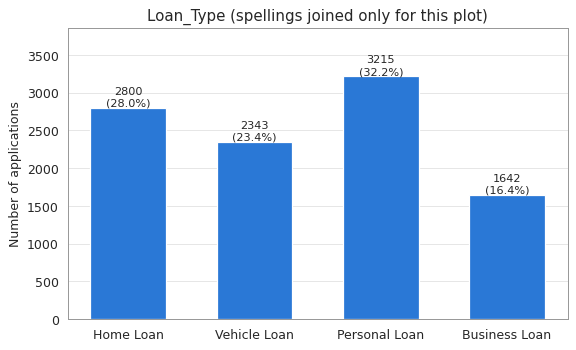

Property_Area (temporary clean view)
               count  percent
Property_Area                
Urban           4905    49.05
Semi-Urban      2947    29.47
Rural           1999    19.99
NaN              149     1.49


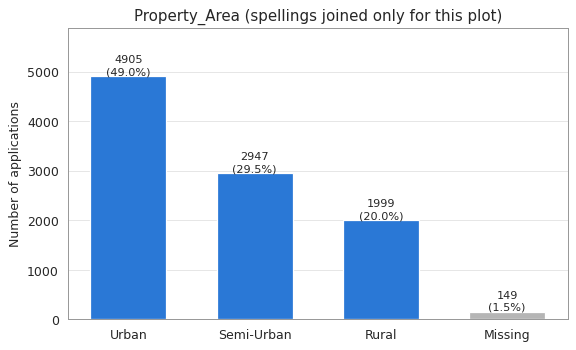

In [23]:
for col in cat_cols:
    cleaned = temp_clean(col)
    print('=' * 50)
    print(col, '(temporary clean view)')
    table = pd.DataFrame({'count': cleaned.value_counts(dropna=False),
                          'percent': (cleaned.value_counts(dropna=False, normalize=True) * 100).round(2)})
    print(table)
    file_name = 'uni_cat_' + col.lower() + '.png'
    plot_category_counts(cleaned, col + ' (spellings joined only for this plot)', file_name,
                         order=valid_categories[col])

**Observation (categorical columns, temporary clean view):**

| Column | What we see |
|---|---|
| Gender | Male 69.8%, Female 27.8%, **Transgender only 60 rows (0.6%)**, missing 1.8%. The very small Transgender group will need care in the fairness audit (too few rows for strong conclusions). |
| Marital_Status | Married 74.1%, Single 22.9%, Divorced 1.0%, Widowed 0.9%, missing 1.2%. Divorced and Widowed are rare. |
| Dependents | 0 → 27.4%, 1 → 26.9%, 2 → 25.0%, 3+ → 18.4%, missing 2.4%. Fairly even spread. |
| Employment_Type | Salaried 60.5%, Self-Employed Non-Professional 24.5%, Self-Employed Professional 15.0%. No missing values. |
| Loan_Type | Personal 32.2%, Home 28.0%, Vehicle 23.4%, Business 16.4%. No missing values. All four types have enough rows. |
| Property_Area | Urban 49.0%, Semi-Urban 29.5%, Rural 20.0%, missing 1.5%. |

Gender and Marital_Status are **protected attributes**. They are useful for the fairness audit, but domain rules (RBI Fair Practices Code) say lending should not discriminate on such grounds.

### C3. Numerical columns

For every numeric column we:
1. count missing values,
2. count **invalid** values using `valid_range` from Part A,
3. hide the invalid values **only in the plot** (so the shape is visible),
4. find the shape (skewness) and the outliers (IQR rule: below Q1 − 1.5×IQR or above Q3 + 1.5×IQR),
5. draw a histogram and a boxplot.

For money columns the **histogram** uses a **log x-axis**, because a few very large values squeeze the rest of the plot. This changes only the picture, not the data. The **boxplot stays on the normal scale**, so its dots match the IQR outlier count.

In [24]:
numeric_summary = []   # one row per column, shown as a table at the end


def get_stats(values):
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    n_outliers = ((values < lower_fence) | (values > upper_fence)).sum()
    stats = {
        'values_used': len(values),
        'min': values.min(),
        'q1': q1,
        'median': values.median(),
        'mean': round(values.mean(), 2),
        'q3': q3,
        'max': values.max(),
        'skewness': round(values.skew(), 2),
        'iqr_outliers': n_outliers,
    }
    return stats


def plot_numeric(values, col, file_name, x_label, log_x=False, note='', discrete=False):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [2, 1]})
    if discrete:
        # whole numbers (like age in years): one bar for each value
        sns.histplot(values, discrete=True, kde=True, color=MAIN_COLOR, ax=axes[0])
    else:
        sns.histplot(values, bins=40, kde=True, color=MAIN_COLOR, ax=axes[0], log_scale=log_x)
    axes[0].set_title(col + ' - histogram')
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel('Number of applications')
    # boxplot always on normal scale, so the dots match the IQR outlier count
    sns.boxplot(x=values, color=MAIN_COLOR, ax=axes[1], width=0.4,
                flierprops={'markersize': 3, 'markerfacecolor': MAIN_COLOR})
    axes[1].set_title(col + ' - boxplot')
    axes[1].set_xlabel(x_label)
    if note != '':
        fig.text(0.01, -0.04, note, fontsize=9, color='#555555')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, file_name), dpi=150, bbox_inches='tight')
    plt.show()


def analyse_numeric(col, values, file_name, x_label, log_x=False, extra_note='', discrete=False):
    # values = the column we want to study (missing values already removed)
    low = valid_range[col][0]
    high = valid_range[col][1]
    if high is None:
        is_valid = values >= low
    else:
        is_valid = (values >= low) & (values <= high)

    invalid_values = values[~is_valid]
    good_values = values[is_valid]
    print('Invalid values (outside', low, 'to', high, '):', len(invalid_values))
    if len(invalid_values) > 0:
        print('Invalid values seen:', sorted(invalid_values.unique().tolist())[:15])

    stats = get_stats(good_values)
    print()
    for key in stats:
        print('   ', key, ':', stats[key])

    row = {'column': col, 'missing': df[col].isnull().sum(), 'invalid': len(invalid_values)}
    row.update(stats)
    numeric_summary.append(row)

    note = ''
    if len(invalid_values) > 0:
        note = str(len(invalid_values)) + ' invalid values are hidden from this plot. '
    note = note + extra_note
    plot_numeric(good_values, col, file_name, x_label, log_x, note, discrete)

#### Age

Missing: 0
Age 18 to 20 (below the usual bank minimum of 21): 153
Invalid values (outside 18 to 75 ): 29
Invalid values seen: [-30.0, 0.0, 1.0, 5.0, 150.0, 200.0, 999.0]

    values_used : 9971
    min : 20.0
    q1 : 31.0
    median : 37.0
    mean : 37.47
    q3 : 43.0
    max : 70.0
    skewness : 0.35
    iqr_outliers : 63


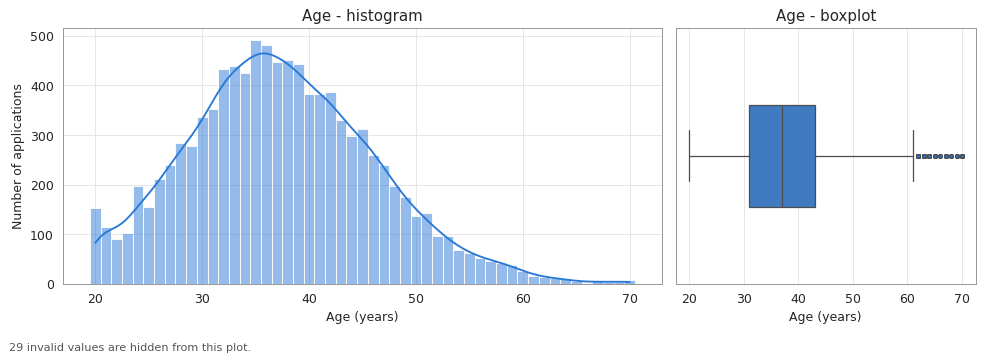

In [25]:
age = df['Age'].dropna()
print('Missing:', df['Age'].isnull().sum())
print('Age 18 to 20 (below the usual bank minimum of 21):', ((age >= 18) & (age < 21)).sum())
analyse_numeric('Age', age, 'uni_num_age.png', 'Age (years)', discrete=True)

**Observation (Age):**
- **29 impossible ages**: −30, 0, 1, 5, 150, 200, 999. These are typing errors.
- Valid ages are **20 to 70**, median **37**. The shape is close to normal with a slightly longer right tail (skewness 0.35).
- The 63 IQR outliers are applicants above 61 years. These are **real older applicants, not errors**.
- **153 applicants are 20 years old**, which is below the usual bank minimum age of 21.

#### Work_Experience

Missing: 301
Negative experience: 15
More than 50 years : 10
Exactly 0 years    : 677
Invalid values (outside 0 to 50 ): 25
Invalid values seen: [-3.0, -2.0, -1.0, 51.0, 54.0, 55.0, 57.0, 62.0, 71.0]

    values_used : 9674
    min : 0.0
    q1 : 7.0
    median : 13.0
    mean : 13.53
    q3 : 19.0
    max : 50.0
    skewness : 0.5
    iqr_outliers : 74


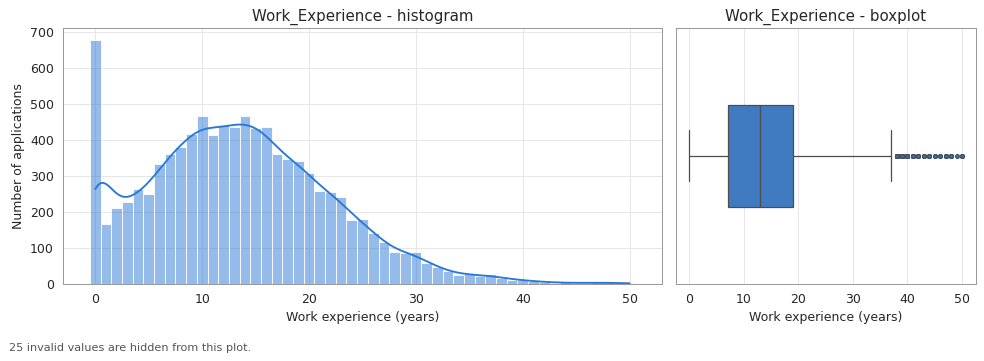

In [26]:
experience = df['Work_Experience'].dropna()
print('Missing:', df['Work_Experience'].isnull().sum())
print('Negative experience:', (experience < 0).sum())
print('More than 50 years :', (experience > 50).sum())
print('Exactly 0 years    :', (experience == 0).sum())
analyse_numeric('Work_Experience', experience, 'uni_num_work_experience.png', 'Work experience (years)', discrete=True)

**Observation (Work_Experience):**
- 301 missing. **25 invalid**: 15 negative (−3 to −1) and 10 above 50 years (up to 71).
- Valid values: median **13 years**, slight right skew (0.50). The 74 IQR outliers (above 37 years) are possible for older applicants.
- **677 applicants have 0 years** of experience (the tall first bar). Banks usually want at least 1 year (salaried) or 3 years (business), so these rows matter.
- Experience cannot be more than (age − 18). That needs two columns, so **Phase 2 will check it**.

#### Monthly_Income

Missing: 99
Negative income: 22
Zero income    : 8
Size of negative values (without minus sign): min 8000.0 | median 69550.0 | max 212100.0
Income between 1 and 14,999 (below usual bank minimum of Rs. 15,000): 193
Invalid values (outside 1 to None ): 30
Invalid values seen: [-212100.0, -171100.0, -162500.0, -133300.0, -110600.0, -108600.0, -108500.0, -99100.0, -77500.0, -75800.0, -71500.0, -67600.0, -51500.0, -43900.0, -43300.0]

    values_used : 9871
    min : 8000.0
    q1 : 35500.0
    median : 55300.0
    mean : 73721.64
    q3 : 87900.0
    max : 1072200.0
    skewness : 3.72
    iqr_outliers : 689


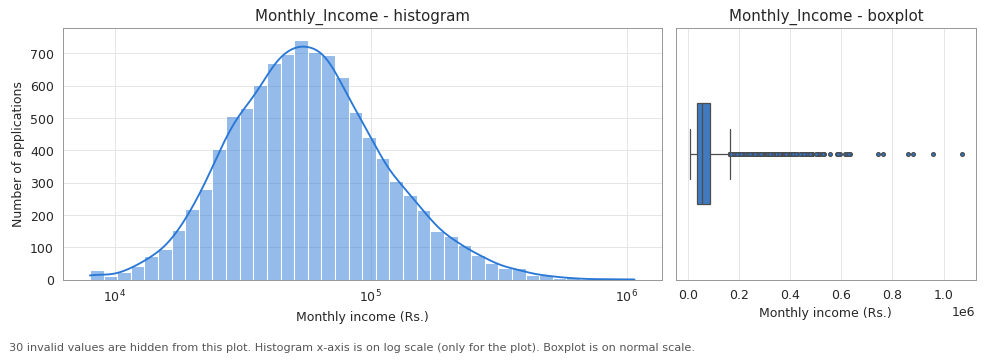

In [27]:
income = df['Monthly_Income'].dropna()
print('Missing:', df['Monthly_Income'].isnull().sum())
print('Negative income:', (income < 0).sum())
print('Zero income    :', (income == 0).sum())
print('Size of negative values (without minus sign): min', (-income[income < 0]).min(),
      '| median', (-income[income < 0]).median(), '| max', (-income[income < 0]).max())
print('Income between 1 and 14,999 (below usual bank minimum of Rs. 15,000):', ((income > 0) & (income < 15000)).sum())
analyse_numeric('Monthly_Income', income, 'uni_num_monthly_income.png', 'Monthly income (Rs.)',
                log_x=True, extra_note='Histogram x-axis is on log scale (only for the plot). Boxplot is on normal scale.')

**Observation (Monthly_Income):**
- 99 missing. **22 negative** and **8 zero** incomes.
- The negative values (size ₹8,000 to ₹2,12,100, median ₹69,550) look like **normal incomes with a wrong minus sign**, not random junk.
- Valid incomes: **₹8,000 to ₹10,72,200 per month**, median **₹55,300**, mean **₹73,722**. The mean is much bigger than the median, so the data is **strongly right-skewed (skewness 3.72)**.
- **689 IQR outliers** (above about ₹1,66,500). These are high earners and are real, not errors.
- On the log-scale plot the shape looks like a bell. This tells Phase 3 that a log transform may help.
- 193 applicants earn less than ₹15,000 (the usual bank minimum).

#### Coapplicant_Income

Missing: 6787 (67.9% of rows)
Invalid values (outside 1 to None ): 0

    values_used : 3213
    min : 4600.0
    q1 : 24000.0
    median : 35400.0
    mean : 42255.28
    q3 : 52900.0
    max : 550900.0
    skewness : 3.73
    iqr_outliers : 136


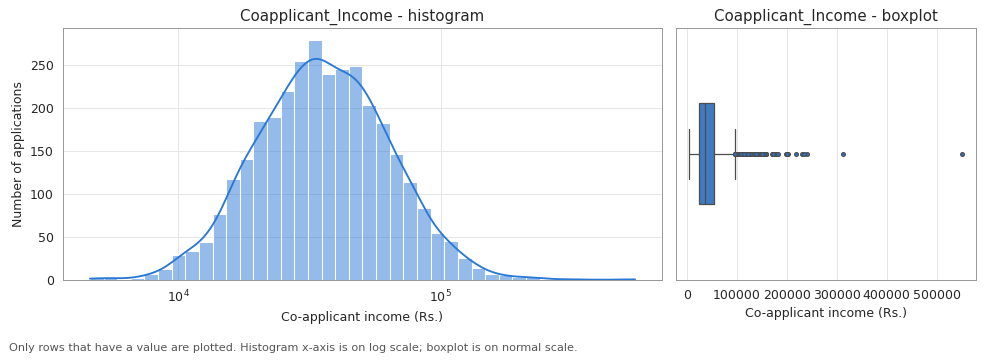

In [28]:
co_income = df['Coapplicant_Income'].dropna()
co_missing = df['Coapplicant_Income'].isnull().sum()
print('Missing:', co_missing, '(' + str(round(co_missing / n_rows * 100, 1)) + '% of rows)')
analyse_numeric('Coapplicant_Income', co_income, 'uni_num_coapplicant_income.png', 'Co-applicant income (Rs.)',
                log_x=True, extra_note='Only rows that have a value are plotted. Histogram x-axis is on log scale; boxplot is on normal scale.')

**Observation (Coapplicant_Income):**
- **6,787 missing (67.9%)**. Every value that is present is **above 0** (minimum ₹4,600). There is **no row with 0**.
  This strongly suggests that a **blank means "no earning co-applicant"**, not "unknown". (To be confirmed in Phase 2.)
- Present values: median **₹35,400**, strongly right-skewed (3.73), 136 IQR outliers.

#### Existing_EMI

Missing: 252
Negative EMI: 0
EMI = 0 (no existing loan): 6022 (61.8% of filled rows)
Invalid values (outside 0 to None ): 0

    values_used : 3726
    min : 100.0
    q1 : 5300.0
    median : 10900.0
    mean : 16032.72
    q3 : 20700.0
    max : 212900.0
    skewness : 2.91
    iqr_outliers : 223


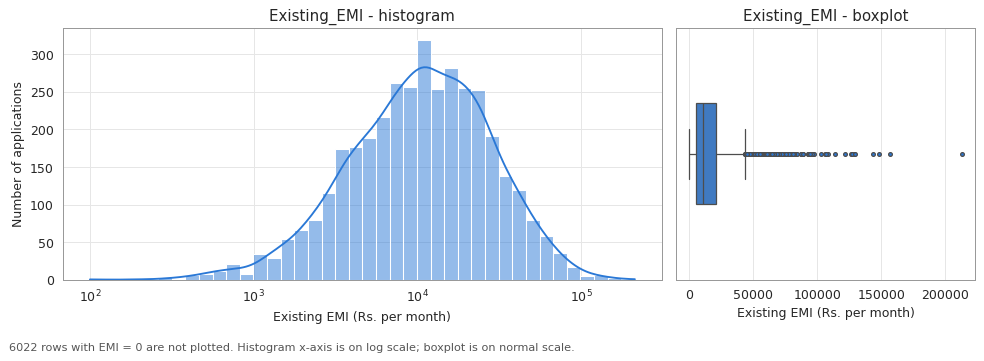

In [29]:
emi = df['Existing_EMI'].dropna()
emi_zero = (emi == 0).sum()
print('Missing:', df['Existing_EMI'].isnull().sum())
print('Negative EMI:', (emi < 0).sum())
print('EMI = 0 (no existing loan):', emi_zero, '(' + str(round(emi_zero / len(emi) * 100, 1)) + '% of filled rows)')

# the zeros are valid, but they hide the shape, so we plot only applicants who have an EMI
emi_non_zero = emi[emi > 0]
analyse_numeric('Existing_EMI', emi_non_zero, 'uni_num_existing_emi.png', 'Existing EMI (Rs. per month)',
                log_x=True, extra_note=str(emi_zero) + ' rows with EMI = 0 are not plotted. Histogram x-axis is on log scale; boxplot is on normal scale.')

**Observation (Existing_EMI):**
- 252 missing. No negative values.
- **6,022 applicants (61.8%) have EMI = 0**, meaning no existing loan. This is a valid value, not missing data.
- For applicants who do have an EMI: median **₹10,900**, max ₹2,12,900, right-skewed (2.91), 223 IQR outliers.

#### CIBIL_Score

Missing: 99
CIBIL = -1 (no credit history, valid special value): 602
Scores 300 to 649 (below the usual cut-off of 650): 955
Scores 750 to 900 (good score)                     : 3999
Invalid values (outside 300 to 900 ): 33
Invalid values seen: [0.0, 100.0, 999.0, 1000.0, 9999.0]

    values_used : 9266
    min : 436.0
    q1 : 695.0
    median : 739.0
    mean : 734.41
    q3 : 780.0
    max : 900.0
    skewness : -0.42
    iqr_outliers : 131


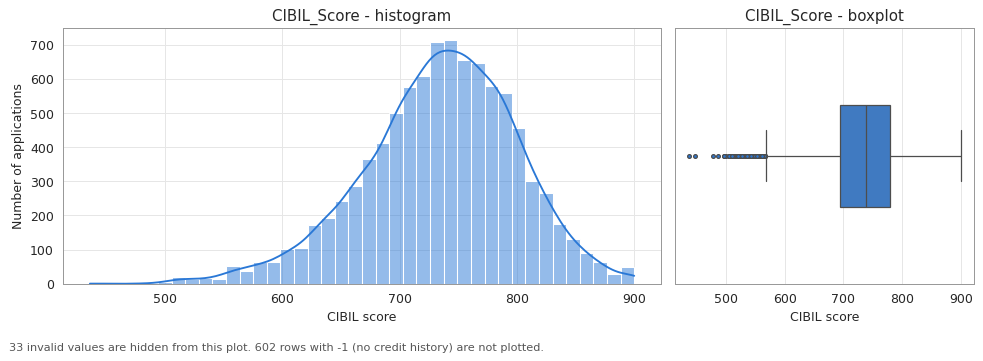

In [30]:
cibil = df['CIBIL_Score'].dropna()
ntc_count = (cibil == -1).sum()
print('Missing:', df['CIBIL_Score'].isnull().sum())
print('CIBIL = -1 (no credit history, valid special value):', ntc_count)

# -1 is a special code, not a score, so we keep it out of the score plot
scored = cibil[cibil != -1]
print('Scores 300 to 649 (below the usual cut-off of 650):', ((scored >= 300) & (scored < 650)).sum())
print('Scores 750 to 900 (good score)                     :', ((scored >= 750) & (scored <= 900)).sum())
analyse_numeric('CIBIL_Score', scored, 'uni_num_cibil_score.png', 'CIBIL score',
                extra_note=str(ntc_count) + ' rows with -1 (no credit history) are not plotted.')

**Observation (CIBIL_Score):**
- 99 missing. **602 rows (6%) have −1**. This is the bureau's code for "no credit history" (new to credit). It is **not a very low score** and must not be treated as one.
- **33 invalid scores**: 0, 100, 999, 1000, 9999.
- Valid scores: **436 to 900**, median **739**. The tail is on the left side (skewness −0.42): a group of applicants has low scores.
- **955 applicants score below 650** (a common bank cut-off) and **3,999 score 750 or more** (a good score).
- The 131 IQR outliers are low scores (below about 567). These are real weak borrowers, not errors.

#### Loan_Amount

Loan_Amount is stored as text (see Q3). **Only for this plot** we remove `Rs.` and commas and turn it into a number.

Missing before temporary fix: 152
Missing after temporary fix : 152 (same number = no value was lost)
Loans up to Rs. 1.5 lakh     : 1214
Loans of Rs. 1 crore or more : 112
Invalid values (outside 1 to None ): 0

    values_used : 9848
    min : 50000.0
    q1 : 300000.0
    median : 680000.0
    mean : 1494442.53
    q3 : 1802500.0
    max : 30000000.0
    skewness : 3.73
    iqr_outliers : 857


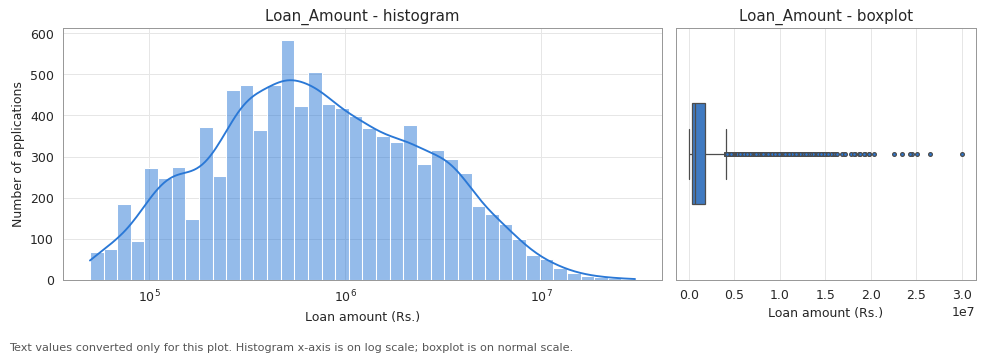

In [31]:
amount_temp = df['Loan_Amount'].str.replace('Rs.', '', regex=False)
amount_temp = amount_temp.str.replace(',', '', regex=False).str.strip()
amount_temp = pd.to_numeric(amount_temp, errors='coerce')

print('Missing before temporary fix:', df['Loan_Amount'].isnull().sum())
print('Missing after temporary fix :', amount_temp.isnull().sum(), '(same number = no value was lost)')
print('Loans up to Rs. 1.5 lakh     :', (amount_temp <= 150000).sum())
print('Loans of Rs. 1 crore or more :', (amount_temp >= 10000000).sum())

analyse_numeric('Loan_Amount', amount_temp.dropna(), 'uni_num_loan_amount.png', 'Loan amount (Rs.)',
                log_x=True, extra_note='Text values converted only for this plot. Histogram x-axis is on log scale; boxplot is on normal scale.')

**Observation (Loan_Amount):**
- 152 missing. After the temporary text-to-number change, **no value was lost**, so all 584 text values can be converted in Phase 3.
- Values go from **₹50,000 to ₹3 crore**. Median **₹6.8 lakh**, mean **₹14.9 lakh**, strongly right-skewed (3.73).
- **857 IQR outliers** (above about ₹40.6 lakh). These are probably home loans, which are naturally large. **Phase 2 should check the amount by Loan_Type.**
- 1,214 loans are up to ₹1.5 lakh (small loans, maybe two-wheelers) and 112 loans are ₹1 crore or more.

#### Loan_Tenure

In [32]:
tenure = df['Loan_Tenure'].dropna()
print('Missing:', df['Loan_Tenure'].isnull().sum())
print()
tenure_counts = tenure.value_counts().sort_index()
print(tenure_counts)

not_multiple_of_12 = tenure[tenure % 12 != 0]
print()
print('Tenures that are not a multiple of 12 months:', len(not_multiple_of_12))
print('These values:', sorted(not_multiple_of_12.unique().tolist()))

Missing: 181

Loan_Tenure
10.0       14
12.0      584
15.0       26
20.0       40
24.0     1042
25.0       13
30.0        2
36.0     1831
48.0     1294
60.0     1831
84.0      413
120.0     460
180.0     804
240.0     915
300.0     406
360.0     144
Name: count, dtype: int64

Tenures that are not a multiple of 12 months: 95
These values: [10.0, 15.0, 20.0, 25.0, 30.0]


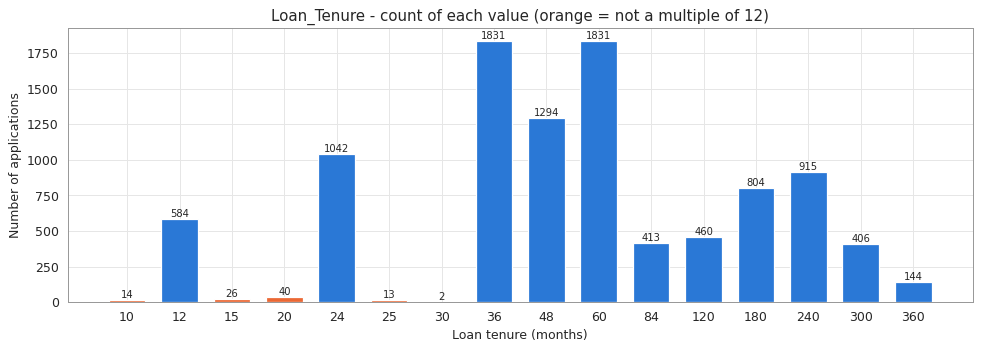

In [33]:
# Tenure has only a few fixed values, so a bar chart is better than a histogram
colors = []
for value in tenure_counts.index:
    if value % 12 == 0:
        colors.append(MAIN_COLOR)
    else:
        colors.append(PROBLEM_COLOR)

labels = []
for value in tenure_counts.index:
    labels.append(str(int(value)))

plt.figure(figsize=(11, 4))
bars = plt.bar(labels, tenure_counts.values, color=colors, width=0.7)
for bar, value in zip(bars, tenure_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 15, str(value), ha='center', fontsize=8)
plt.title('Loan_Tenure - count of each value (orange = not a multiple of 12)')
plt.xlabel('Loan tenure (months)')
plt.ylabel('Number of applications')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'uni_num_loan_tenure.png'), dpi=150)
plt.show()

# add tenure to the summary table (stats on all filled values)
row = {'column': 'Loan_Tenure', 'missing': df['Loan_Tenure'].isnull().sum(), 'invalid': len(not_multiple_of_12)}
row.update(get_stats(tenure[tenure % 12 == 0]))   # same idea as other columns: stats without the odd values
numeric_summary.append(row)

**Observation (Loan_Tenure):**
- 181 missing. Only **16 different values**. The most common are **36 and 60 months** (1,831 each).
- Almost all values are multiples of 12 (whole years), **except 10, 15, 20, 25 and 30 (95 rows, in orange)**.
  These look like tenure written in **years instead of months** (for example, 20 years = 240 months). **Phase 2 should check which loan type these rows have.**
- The 550 IQR outliers are tenures of 300 and 360 months (25–30 years). These are normal for home loans, so they are real values.

#### Collateral_Value

Missing: 4250 (42.5% of rows)
Invalid values (outside 1 to None ): 0

    values_used : 5750
    min : 50000.0
    q1 : 580000.0
    median : 1720000.0
    mean : 3207523.48
    q3 : 4270000.0
    max : 60850000.0
    skewness : 3.53
    iqr_outliers : 390


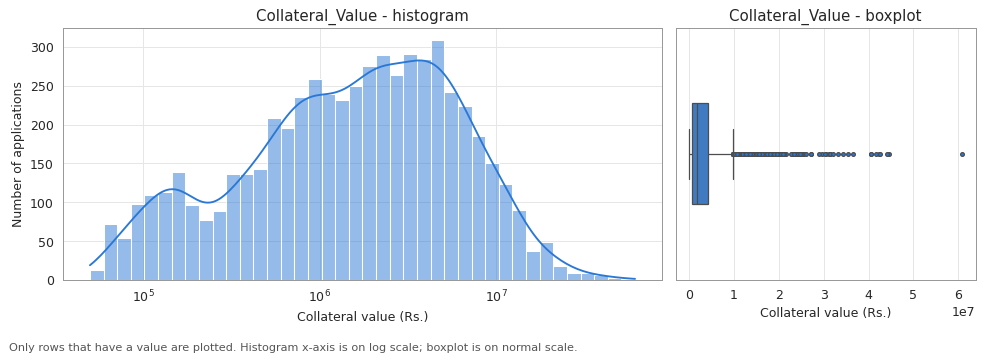

In [34]:
collateral = df['Collateral_Value'].dropna()
coll_missing = df['Collateral_Value'].isnull().sum()
print('Missing:', coll_missing, '(' + str(round(coll_missing / n_rows * 100, 1)) + '% of rows)')
analyse_numeric('Collateral_Value', collateral, 'uni_num_collateral_value.png', 'Collateral value (Rs.)',
                log_x=True, extra_note='Only rows that have a value are plotted. Histogram x-axis is on log scale; boxplot is on normal scale.')

**Observation (Collateral_Value):**
- **4,250 missing (42.5%)**. All present values are above 0, so a blank probably means **no collateral (unsecured loan)**. Phase 2 should check this against Loan_Type.
- Present values: **₹50,000 to ₹6.09 crore**, median **₹17.2 lakh**, right-skewed (3.53), 390 IQR outliers.
- The log-scale histogram has **two humps**: a small one around ₹1–2 lakh and a big one around ₹20–50 lakh. This is probably **vehicles vs property**. Phase 2 can confirm it with Loan_Type.

### C4. Summary of all numeric columns

`invalid` = values outside the valid range from Part A (for Loan_Tenure: values that are not a multiple of 12). Statistics are calculated **without** the invalid values.

In [35]:
numeric_summary_table = pd.DataFrame(numeric_summary)
numeric_summary_table = numeric_summary_table.set_index('column')
numeric_summary_table.round(2)

,missing,invalid,values_used,min,q1,median,mean,q3,max,skewness,iqr_outliers
column,,,,,,,,,,,
Age,0,29,9971,20.0,31.0,37.0,37.47,43.0,70.0,0.35,63
Work_Experience,301,25,9674,0.0,7.0,13.0,13.53,19.0,50.0,0.50,74
Monthly_Income,99,30,9871,8000.0,35500.0,55300.0,73721.64,87900.0,1072200.0,3.72,689
Coapplicant_Income,6787,0,3213,4600.0,24000.0,35400.0,42255.28,52900.0,550900.0,3.73,136
Existing_EMI,252,0,3726,100.0,5300.0,10900.0,16032.72,20700.0,212900.0,2.91,223
CIBIL_Score,99,33,9266,436.0,695.0,739.0,734.41,780.0,900.0,-0.42,131
Loan_Amount,152,0,9848,50000.0,300000.0,680000.0,1494442.53,1802500.0,30000000.0,3.73,857
Loan_Tenure,181,95,9724,12.0,36.0,60.0,92.32,120.0,360.0,1.38,550
Collateral_Value,4250,0,5750,50000.0,580000.0,1720000.0,3207523.48,4270000.0,60850000.0,3.53,390


**Observation (summary):**
- **Nearly symmetric:** Age, Work_Experience, CIBIL_Score (|skewness| ≤ 0.5).
- **Strongly right-skewed:** all money columns (Monthly_Income, Coapplicant_Income, Existing_EMI, Loan_Amount, Collateral_Value), with skewness about 3 to 3.7.
- Most IQR outliers in the money columns are **real large values** (rich applicants, big home loans), **not errors**. Removing them would delete real customers. The true errors are the **invalid** values.

## Part D: List of problems found (for Phase 2 and Phase 3)

Nothing below has been fixed. This list is the hand-over to the next phases.

In [36]:
issues = [
    ['Loan_ID / all', 'Exact duplicate rows', n_dup_rows, 'Phase 3: remove duplicates'],
    ['Loan_Status', 'Target is missing', n_missing_target, 'Phase 3: drop these rows (never guess the target)'],
    ['5 text columns', 'Many spellings for the same category + extra spaces',
     int(spelling_table['rows_not_in_valid_list'].sum()), 'Phase 3: map to real categories (plot_map can be reused)'],
    ['Loan_Amount', 'Number stored as text ("12,50,000", "Rs. ...")', amount_text_count, 'Phase 3: remove Rs. and commas, convert to number'],
    ['Dependents', 'Text value "3+"', dependents_3plus, 'Phase 3: convert to number (3)'],
    ['Age', 'Impossible age (outside 18-75)', numeric_summary_table.loc['Age', 'invalid'], 'Phase 3: treat as missing'],
    ['Work_Experience', 'Negative or more than 50 years', numeric_summary_table.loc['Work_Experience', 'invalid'], 'Phase 2: also compare with Age. Phase 3: treat as missing'],
    ['Monthly_Income', 'Negative income', (income < 0).sum(), 'Phase 3: looks like a sign error (check, then fix)'],
    ['Monthly_Income', 'Zero income', (income == 0).sum(), 'Phase 3: treat as missing'],
    ['CIBIL_Score', 'Outside 300-900 (not -1)', numeric_summary_table.loc['CIBIL_Score', 'invalid'], 'Phase 3: treat as missing'],
    ['CIBIL_Score', '-1 = no credit history (valid, special)', ntc_count, 'Phase 3/4: keep the meaning (e.g. a flag), do not treat as a low score'],
    ['Loan_Tenure', 'Not a multiple of 12 (10, 15, 20, 25, 30)', len(not_multiple_of_12), 'Phase 2: check loan type. Possibly years typed instead of months'],
    ['Coapplicant_Income', 'Very high missing %', co_missing, 'Phase 2: check if blank = no co-applicant'],
    ['Collateral_Value', 'Very high missing %', coll_missing, 'Phase 2: check if blank = unsecured loan type'],
    ['Many columns', 'Small random missing values (1-3%)', '', 'Phase 3: fill (impute)'],
    ['Money columns', 'Strong right skew and many IQR outliers', '', 'Phase 3: keep real large values; decide transform/capping'],
]
issues_table = pd.DataFrame(issues, columns=['column', 'problem', 'count', 'next step (suggestion)'])
issues_table

,column,problem,count,next step (suggestion)
0,Loan_ID / all,Exact duplicate rows,135,Phase 3: remove duplicates
1,Loan_Status,Target is missing,18,Phase 3: drop these rows (never guess the target)
2,5 text columns,Many spellings for the same category + extra s...,4861,Phase 3: map to real categories (plot_map can ...
3,Loan_Amount,"Number stored as text (""12,50,000"", ""Rs. ..."")",584,"Phase 3: remove Rs. and commas, convert to number"
4,Dependents,"Text value ""3+""",1840,Phase 3: convert to number (3)
5,Age,Impossible age (outside 18-75),29,Phase 3: treat as missing
6,Work_Experience,Negative or more than 50 years,25,Phase 2: also compare with Age. Phase 3: treat...
7,Monthly_Income,Negative income,22,"Phase 3: looks like a sign error (check, then ..."
8,Monthly_Income,Zero income,8,Phase 3: treat as missing
9,CIBIL_Score,Outside 300-900 (not -1),33,Phase 3: treat as missing


### Final check: the real data was not changed in this phase

In [37]:
check_df = pd.read_csv(DATA_PATH)
print('Data still the same as the raw file:', df.equals(check_df))
print('Shape:', df.shape)

Data still the same as the raw file: True
Shape: (10000, 17)
